# Transformer Encoder tự viết từ đầu (PyTorch thuần) cho phát hiện bình luận độc hại — ViHSD

Đây là phiên bản **tự cài đặt kiến trúc Transformer Encoder bằng PyTorch từ đầu**, thay vì dùng model
pretrained (PhoBERT) như notebook `vihsd_phobert_toxic_detection.ipynb`. Mục tiêu là chứng minh hiểu rõ
cơ chế bên trong Transformer (embedding, positional encoding, multi-head self-attention, feed-forward,
residual + layer norm) và huấn luyện toàn bộ trọng số **từ ngẫu nhiên** (không pretrained) trên chính
dataset ViHSD.

## "Từ đầu" nghĩa là gì trong notebook này?

- **Có dùng**: `torch.nn.Linear`, `nn.Embedding`, `nn.LayerNorm`, `nn.Dropout`, `nn.Parameter`,
  `torch.optim` — các building block cơ bản của PyTorch (không có framework nào cung cấp Transformer
  "miễn phí" từ những thành phần này).
- **Không dùng**: `nn.MultiheadAttention`, `nn.TransformerEncoder(Layer)`, HuggingFace `transformers`,
  bất kỳ pretrained embedding/model nào (PhoBERT, BERT, word2vec,...). Toàn bộ attention, feed-forward,
  positional encoding, training loop, vocab đều tự viết tay.

## Khác biệt so với phiên bản PhoBERT

| | PhoBERT (fine-tune) | Transformer from-scratch |
|---|---|---|
| Trọng số ban đầu | Pretrained trên ~20GB tiếng Việt | Ngẫu nhiên |
| Tokenizer | BPE của PhoBERT | Vocab word-level tự xây từ tập train |
| Kỳ vọng kết quả | Cao (tận dụng kiến thức ngôn ngữ có sẵn) | Thấp hơn — chỉ học từ ~24k câu, nhưng minh hoạ đúng
bản chất kiến trúc |

> Notebook dùng lại các bước tải dữ liệu & tiền xử lý giống phiên bản PhoBERT để đảm bảo so sánh công bằng
> (cùng train/dev/test, cùng cách làm sạch + tách từ).

## 1. Cài đặt & import thư viện

In [1]:
# underthesea dùng để tách từ tiếng Việt (không phải model Transformer, chỉ là công cụ tiền xử lý)
%pip install -q -U scikit-learn seaborn underthesea tqdm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from core.common import set_seed, get_device

tqdm.pandas()

SEED = 42
set_seed(SEED)
device = get_device()

print("Thiết bị sử dụng:", device)


## 2. Tải dataset ViHSD

Giống hệt phiên bản PhoBERT — nếu đã chạy notebook đó rồi thì thư mục `../data/vihsd` đã có sẵn, cell dưới
sẽ tự bỏ qua bước tải.

In [ ]:
from core.data import LABEL_NAMES, load_vihsd

train_raw, dev_raw, test_raw = load_vihsd("../data/vihsd")

print("Train:", train_raw.shape, "| Dev:", dev_raw.shape, "| Test:", test_raw.shape)
train_raw.head()


## 3. Tiền xử lý văn bản

Làm sạch (bỏ URL/mention, lowercase) + tách từ tiếng Việt bằng `underthesea` (từ ghép nối bằng `_`).
Việc tách từ **không phải là một phần của model Transformer** — đây thuần tuý là bước tiền xử lý dữ liệu
đầu vào, tương tự việc PhoBERT cũng cần input đã tách từ.

In [ ]:
from core.preprocessing import clean_text, segment_text, preprocess_df

print("Tiền xử lý train...")
train_df = preprocess_df(train_raw, drop_empty=True, keep_free_text=True)
print("Tiền xử lý dev...")
dev_df = preprocess_df(dev_raw, drop_empty=True, keep_free_text=True)
print("Tiền xử lý test...")
test_df = preprocess_df(test_raw, drop_empty=True, keep_free_text=True)

train_df.head()


## 4. Xây dựng từ điển (vocab) từ đầu

Vì không dùng tokenizer có sẵn (PhoBERT/BPE), ta tự xây vocab **word-level** từ chính tập train:
- Token = một từ (đã tách bằng `underthesea`, các từ ghép nối bằng `_`).
- Loại bỏ từ hiếm (`min_freq`) để tránh vocab quá lớn / overfit vào từ chỉ xuất hiện 1 lần.
- Thêm 2 token đặc biệt: `<pad>` (id=0, dùng để đệm câu ngắn) và `<unk>` (id=1, từ không có trong vocab).

In [5]:
MIN_FREQ = 2

def build_vocab(texts, min_freq=MIN_FREQ):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    word2idx = {"<pad>": 0, "<unk>": 1}
    for word, freq in counter.most_common():
        if freq < min_freq:
            continue
        word2idx[word] = len(word2idx)

    idx2word = {idx: word for word, idx in word2idx.items()}
    return word2idx, idx2word, counter

word2idx, idx2word, word_counter = build_vocab(train_df["segmented_text"])
VOCAB_SIZE = len(word2idx)
PAD_IDX = word2idx["<pad>"]
UNK_IDX = word2idx["<unk>"]

print("Kích thước vocab:", VOCAB_SIZE)
print("Số từ duy nhất trước khi lọc min_freq:", len(word_counter))
print("10 từ phổ biến nhất:", word_counter.most_common(10))

Kích thước vocab: 9428
Số từ duy nhất trước khi lọc min_freq: 24448
10 từ phổ biến nhất: [('.', 4961), (',', 4497), ('là', 3180), ('có', 2925), ('mà', 2197), ('cho', 2039), ('thì', 1959), ('đi', 1939), ('này', 1804), (':', 1798)]


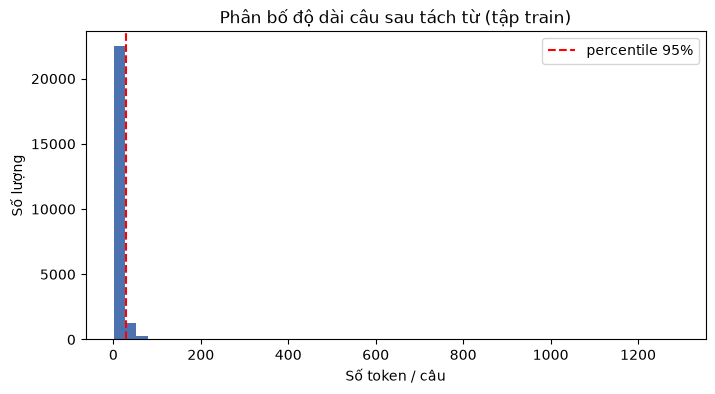

count    24047.000000
mean        10.755770
std         16.861054
min          1.000000
25%          5.000000
50%          8.000000
75%         13.000000
max       1290.000000
Name: segmented_text, dtype: float64
Percentile 95%: 30.0 | 99%: 57.0


In [6]:
# Xác định MAX_LEN dựa trên phân bố độ dài câu (số token) sau khi tách từ
seq_lengths = train_df["segmented_text"].apply(lambda t: len(t.split()))

plt.figure(figsize=(8, 4))
plt.hist(seq_lengths, bins=50, color="#4c72b0")
plt.axvline(seq_lengths.quantile(0.95), color="red", linestyle="--", label="percentile 95%")
plt.xlabel("Số token / câu")
plt.ylabel("Số lượng")
plt.title("Phân bố độ dài câu sau tách từ (tập train)")
plt.legend()
plt.show()

print(seq_lengths.describe())
print("Percentile 95%:", seq_lengths.quantile(0.95), "| 99%:", seq_lengths.quantile(0.99))

In [7]:
MAX_LEN = 48  # điều chỉnh lại theo kết quả cell trên nếu cần (nên bao phủ >95% câu)

def encode_sentence(text: str, word2idx: dict, max_len: int = MAX_LEN) -> list:
    tokens = text.split()
    ids = [word2idx.get(tok, UNK_IDX) for tok in tokens[:max_len]]
    ids = ids + [PAD_IDX] * (max_len - len(ids))
    return ids

# Ví dụ minh họa
example = train_df["segmented_text"].iloc[1]
print("Câu       :", example)
print("Token ids :", encode_sentence(example, word2idx))

Câu       : đúng là bọn mắt híp lò_xo thụt :))) bên việt_nam t cái này ra cách đây 10 năm r và bọn t gọi_là cái l :)))
Token ids : [104, 4, 151, 413, 6275, 1, 4153, 94, 186, 157, 113, 15, 10, 39, 285, 74, 367, 127, 161, 41, 151, 113, 667, 15, 452, 94, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 5. PyTorch `Dataset` / `DataLoader`

In [8]:
class ViHSDDataset(Dataset):
    def __init__(self, df: pd.DataFrame, word2idx: dict, max_len: int = MAX_LEN):
        self.input_ids = [
            encode_sentence(t, word2idx, max_len) for t in df["segmented_text"]
        ]
        self.labels = df["labels"].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.input_ids[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


BATCH_SIZE = 32

train_dataset = ViHSDDataset(train_df, word2idx)
dev_dataset = ViHSDDataset(dev_df, word2idx)
test_dataset = ViHSDDataset(test_df, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Số batch train:", len(train_loader), "| dev:", len(dev_loader), "| test:", len(test_loader))

Số batch train: 752 | dev: 42 | test: 105


## 6. Kiến trúc Transformer Encoder — tự cài đặt từ đầu

### 6.1. Positional Encoding (sinusoidal, công thức gốc trong paper *Attention Is All You Need*)

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right), \quad
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

### 6.2. Multi-Head Self-Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}} + \text{mask}\right)V$$

Tự cài đặt phép chiếu $W_Q, W_K, W_V, W_O$, chia thành nhiều head, và mask các vị trí `<pad>` để mô hình
không "chú ý" vào phần đệm.

In [10]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model phải chia hết cho n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, _ = x.shape

        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # (B, H, T, d_k)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B, H, T, T)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        out = attn_weights @ V  # (B, H, T, d_k)
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.W_o(out), attn_weights

### 6.3. Position-wise Feed-Forward Network

In [11]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)

### 6.4. Encoder Layer (Multi-Head Attention + Feed-Forward, mỗi khối có residual connection + LayerNorm
theo kiến trúc Post-LN của paper gốc)

In [12]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, attn_weights = self.attn(x, mask)
        x = self.norm1(x + self.dropout(attn_out))       # residual + norm sau attention

        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))          # residual + norm sau feed-forward
        return x, attn_weights

### 6.5. Toàn bộ model: Embedding → Positional Encoding → N × Encoder Layer → Mean-Pooling → Classifier

Vì đây là bài toán phân loại (không có token `[CLS]` như BERT), ta lấy **mean pooling** trên các vector
đầu ra của các token không phải `<pad>` để tạo biểu diễn cho toàn câu.

In [13]:
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        n_heads: int,
        d_ff: int,
        n_layers: int,
        num_classes: int,
        max_len: int,
        dropout: float = 0.1,
        pad_idx: int = 0,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.d_model = d_model

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList(
            [TransformerEncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids):
        pad_mask = (input_ids != self.pad_idx)  # (B, T) True = token thật
        attn_mask = pad_mask.unsqueeze(1).unsqueeze(2)  # (B, 1, 1, T) broadcast cho mọi head/query

        x = self.embedding(input_ids) * math.sqrt(self.d_model)  # scale embedding như paper gốc
        x = self.pos_encoding(x)
        x = self.dropout(x)

        for layer in self.layers:
            x, _ = layer(x, attn_mask)

        # Mean pooling trên các token không phải <pad>
        mask_f = pad_mask.unsqueeze(-1).float()
        summed = (x * mask_f).sum(dim=1)
        counts = mask_f.sum(dim=1).clamp(min=1e-9)
        pooled = summed / counts

        return self.classifier(pooled)

## 7. Cấu hình model & xử lý mất cân bằng lớp

In [ ]:
from core.evaluation import compute_class_weights

class_weights = compute_class_weights(train_df["labels"].values, device=device)
print("Class weights (CLEAN, OFFENSIVE, HATE):", class_weights)


In [15]:
D_MODEL = 128
N_HEADS = 4
D_FF = 512
N_LAYERS = 3
DROPOUT = 0.1
NUM_CLASSES = 3
EPOCHS = 15

model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    n_layers=N_LAYERS,
    num_classes=NUM_CLASSES,
    max_len=MAX_LEN,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Tổng số tham số huấn luyện được: {num_params:,}")
model

Tổng số tham số huấn luyện được: 1,801,987


TransformerClassifier(
  (embedding): Embedding(9428, 128, padding_idx=0)
  (pos_encoding): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-2): 3 x TransformerEncoderLayer(
      (attn): MultiHeadSelfAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
        )
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (norm2): LayerNorm((128,), eps=1e-05

## 8. Training loop (viết tay, không dùng `Trainer`)

Optimizer Adam + **learning rate schedule kiểu Noam** (warm-up rồi giảm dần theo $step^{-0.5}$), đúng như
đề xuất trong paper *Attention Is All You Need* — thường cần thiết để ổn định huấn luyện Transformer từ đầu.

In [16]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.98), eps=1e-9)

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * EPOCHS
WARMUP_STEPS = max(total_steps // 10, 1)

def noam_lr_lambda(step):
    step = max(step, 1)
    return (D_MODEL ** -0.5) * min(step ** -0.5, step * (WARMUP_STEPS ** -1.5))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, noam_lr_lambda)

print(f"Steps/epoch: {steps_per_epoch} | Total steps: {total_steps} | Warmup steps: {WARMUP_STEPS}")

Steps/epoch: 752 | Total steps: 11280 | Warmup steps: 1128


In [17]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, data_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(device)
            logits = model(input_ids)
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return acc, f1_macro, np.array(all_labels), np.array(all_preds)

In [18]:
train_losses, val_accs, val_f1s = [], [], []
best_f1_macro = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for input_ids, labels in progress:
        input_ids, labels = input_ids.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * input_ids.size(0)
        progress.set_postfix(loss=loss.item())

    avg_train_loss = total_loss / len(train_dataset)
    val_acc, val_f1_macro, _, _ = evaluate(model, dev_loader)

    train_losses.append(avg_train_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1_macro)

    print(f"Epoch {epoch}/{EPOCHS} | train_loss={avg_train_loss:.4f} | "
          f"val_acc={val_acc:.4f} | val_f1_macro={val_f1_macro:.4f}")

    if val_f1_macro > best_f1_macro:
        best_f1_macro = val_f1_macro
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
print(f"\nĐã nạp lại trọng số tốt nhất theo dev macro-F1 = {best_f1_macro:.4f}")

Epoch 1/15 | train_loss=1.1181 | val_acc=0.3013 | val_f1_macro=0.2454


Epoch 2/15 | train_loss=1.1014 | val_acc=0.4233 | val_f1_macro=0.3013


Epoch 3/15 | train_loss=1.0884 | val_acc=0.4611 | val_f1_macro=0.3236


Epoch 4/15 | train_loss=1.0842 | val_acc=0.4865 | val_f1_macro=0.3382


Epoch 5/15 | train_loss=1.0729 | val_acc=0.4996 | val_f1_macro=0.3422


...

Epoch 11/15 | train_loss=1.0528 | val_acc=0.5442 | val_f1_macro=0.3757


Epoch 12/15 | train_loss=1.0515 | val_acc=0.5449 | val_f1_macro=0.3762


Epoch 13/15 | train_loss=1.0498 | val_acc=0.5528 | val_f1_macro=0.3843


Epoch 14/15 | train_loss=1.0483 | val_acc=0.5573 | val_f1_macro=0.3867


Epoch 15/15 | train_loss=1.0435 | val_acc=0.5647 | val_f1_macro=0.3905

Đã nạp lại trọng số tốt nhất theo dev macro-F1 = 0.3905


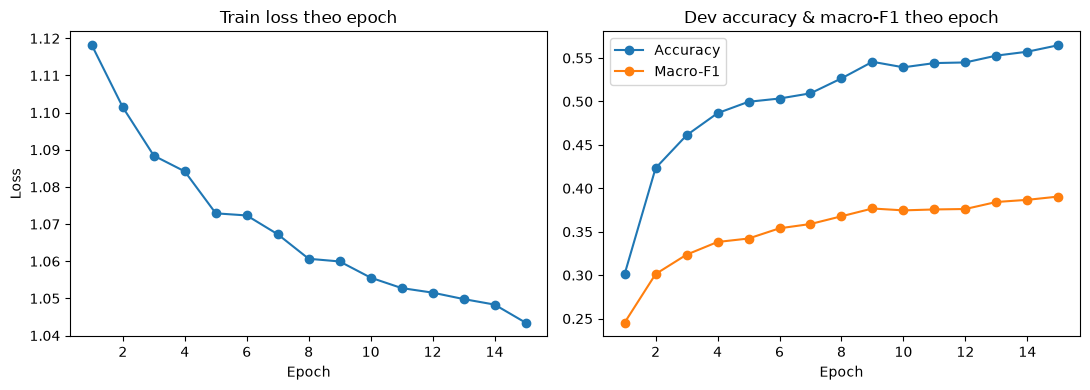

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, EPOCHS + 1), train_losses, marker="o")
axes[0].set_title("Train loss theo epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(range(1, EPOCHS + 1), val_accs, marker="o", label="Accuracy")
axes[1].plot(range(1, EPOCHS + 1), val_f1s, marker="o", label="Macro-F1")
axes[1].set_title("Dev accuracy & macro-F1 theo epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Đánh giá chi tiết trên tập test

In [ ]:
test_acc, test_f1_macro, y_true, y_pred = evaluate(model, test_loader)
print(f"Test accuracy: {test_acc:.4f} | Test macro-F1: {test_f1_macro:.4f}")

from core.evaluation import print_classification_report

print_classification_report(y_true, y_pred, LABEL_NAMES)


In [ ]:
from core.evaluation import plot_confusion_matrix

plot_confusion_matrix(y_true, y_pred, LABEL_NAMES)


In [ ]:
# Dùng test_df (đã qua tiền xử lý, cùng thứ tự với test_loader) để đảm bảo khớp đúng hàng
# với y_true/y_pred — không dùng test_raw trực tiếp vì có thể lệch nếu có dòng bị loại ở bước tiền xử lý.
from core.evaluation import build_misclassified_report

misclassified_sample = build_misclassified_report(test_df, y_true, y_pred, LABEL_NAMES, seed=SEED)
misclassified_sample


## 10. Lưu model & demo inference

In [23]:
import json

SAVE_DIR = Path("../models/transformer-scratch-vihsd")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), SAVE_DIR / "model_state_dict.pt")
with open(SAVE_DIR / "vocab.json", "w", encoding="utf-8") as f:
    json.dump(word2idx, f, ensure_ascii=False)

config = {
    "vocab_size": VOCAB_SIZE, "d_model": D_MODEL, "n_heads": N_HEADS, "d_ff": D_FF,
    "n_layers": N_LAYERS, "num_classes": NUM_CLASSES, "max_len": MAX_LEN,
    "dropout": DROPOUT, "pad_idx": PAD_IDX,
}
with open(SAVE_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Đã lưu model, vocab, config vào:", SAVE_DIR.resolve())

Đã lưu model, vocab, config vào: /Users/yongquan/Documents/Master/demo-transformer/models/transformer-scratch-vihsd


In [24]:
def predict_toxicity(text: str) -> dict:
    model.eval()
    cleaned = clean_text(text)
    segmented = segment_text(cleaned)
    ids = encode_sentence(segmented, word2idx, MAX_LEN)
    input_ids = torch.tensor([ids], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_ids)
    probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred_id = int(np.argmax(probs))

    return {
        "text": text,
        "label": LABEL_NAMES[pred_id],
        "probs": {LABEL_NAMES[i]: round(float(probs[i]), 4) for i in range(3)},
    }


samples = [
    "Video này hay quá, cảm ơn bạn đã chia sẻ nhé",
    "Thằng ngu này nói chuyện chán vãi",
    "Bọn mày là lũ súc vật không hơn không kém",
]

for s in samples:
    result = predict_toxicity(s)
    print(f"[{result['label']}] {result['text']}")
    print("   ", result["probs"])

[CLEAN] Video này hay quá, cảm ơn bạn đã chia sẻ nhé
    {'CLEAN': 0.3742, 'OFFENSIVE': 0.2768, 'HATE': 0.349}
[HATE] Thằng ngu này nói chuyện chán vãi
    {'CLEAN': 0.2193, 'OFFENSIVE': 0.3224, 'HATE': 0.4583}
[HATE] Bọn mày là lũ súc vật không hơn không kém
    {'CLEAN': 0.3209, 'OFFENSIVE': 0.2375, 'HATE': 0.4416}


## 11. Kết luận & so sánh với PhoBERT

**Những gì đã tự cài đặt từ đầu:** embedding + scaling, sinusoidal positional encoding, multi-head
self-attention (bao gồm attention mask cho `<pad>`), feed-forward network, residual connection + layer
norm, mean-pooling classifier, training loop thủ công với Noam learning rate schedule và gradient clipping.

**Kỳ vọng thực tế:** vì không có pretrained knowledge và chỉ học từ ~24k câu, model này thường đạt
**accuracy/macro-F1 thấp hơn đáng kể** so với PhoBERT fine-tune (chú ý đặc biệt ở 2 lớp thiểu số
OFFENSIVE/HATE). Đây là kết quả *hợp lý và có giá trị học thuật* — nó minh chứng vai trò quan trọng của
pretraining trên corpus lớn đối với các ngôn ngữ ít tài nguyên như tiếng Việt.

**Có thể thử để cải thiện:**
- Tăng `n_layers`, `d_model`, hoặc train lâu hơn (dễ overfit hơn do dataset nhỏ — theo dõi dev macro-F1).
- Dùng pretrained word embedding tiếng Việt (fastText, PhoW2V) để khởi tạo `nn.Embedding` thay vì random.
- Thử kiến trúc Pre-LN thay vì Post-LN (thường ổn định hơn khi train từ đầu, ít cần warm-up hơn).
- Data augmentation cho lớp thiểu số, hoặc dùng focal loss thay cho class-weighted cross-entropy.
- So sánh trực tiếp bằng cách chạy notebook PhoBERT (`vihsd_phobert_toxic_detection.ipynb`) và đối chiếu
  bảng classification report của 2 phiên bản trong báo cáo luận văn.